# Dominant Poles - F8 Example

In [1]:
import requests as req, os
URL = "https://raw.githubusercontent.com/mit-acl/16_06_Class/main/"
File = ["basic_material.py","control_materials.py","read_csv_data.py"]
try:
    %run basic_material.py
    print('Basic file found')
except:    
    print('Basic files not` found - downloading it')
    for dfile in File:
        if not os.path.isfile(dfile):
            print(dfile)
            res = req.get(URL+dfile)
            file = open(dfile, 'w')
            file.write(res.text)
            file.close()

try:
    from control.matlab import tf,step, tf2ss, ss2tf, bode
except:
    !python3 -m pip install control
    from control.matlab import tf,step
import control as ct

import scipy
from scipy.signal import residue

Running Python: 3.8.17
Running Sympy: 1.12rc1
Basic file found


# F-8E Example

In [11]:
s = tf('s')
num = 964*(s/0.797+1)*(-s/38.8+1)*(s/36+1)
den = ((s/3.59)**2 + 2*(0.28)/3.59*s + 1)*((s/0.032)**2 + 2*(0.18)/0.032*s + 1)
P = num/den
P

TransferFunction(array([ -12.722,   25.483,  17798.910,  14163.104]), array([ 1113.250,  2250.902,  14374.595,  167.577,   14.692]))

In [12]:
# Very Crude Approximation
num_rr = 964
den_rr = ((s/0.032)**2 + 2*(0.18)/0.032*s + 1)
Prr = num_rr/den_rr
Prr

TransferFunction(array([   0.987]), array([   1.000,    0.012,    0.001]))

In [13]:
#More Advanced Approx covered in 16.30
Pss = tf2ss(P)
Pss_r = ct.balred(Pss, 2, method='truncate', alpha=None)
Pr = ss2tf(Pss_r)
Pr.num[0][0]/0.032**2

array([ 1052.864,  964.375])

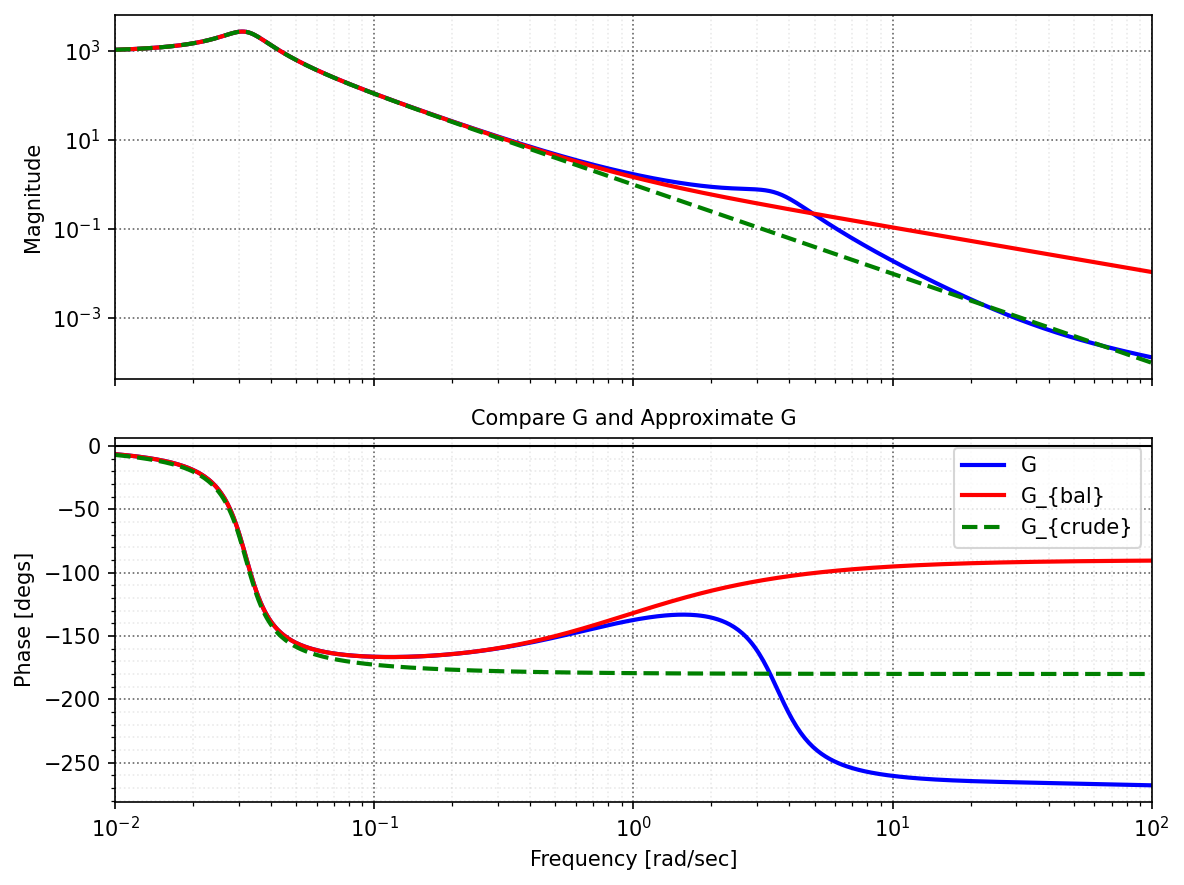

In [14]:
gain, phase, w = bode(P, logspace(-2,2,500),plot=False)
gainr, phaser, wr = bode(Pr, logspace(-2,2,500),plot=False)
gainrr, phaserr, wrr = bode(Prr, logspace(-2,2,500),plot=False)

fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(w,gain,'b-',label='G')
ax[0].loglog(wr,gainr,'r-',label='G_{bal}')
ax[0].loglog(wrr,gainrr,'g--',label='G_{crude}')

ax[1].semilogx(w,phase*r2d,'b-',label='G')
ax[1].semilogx(wr,phaser*r2d,'r-',label='G_{bal}')
ax[1].semilogx(wrr,phaserr*r2d,'g--',label='G_{crude}')

ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")

ax[0].set_ylabel("Magnitude")
plt.title("Compare G and Approximate G")
plt.legend()
nicegrid(ax)
savefig("./figs/DP_Ex41.pdf", dpi=600)
plt.show()

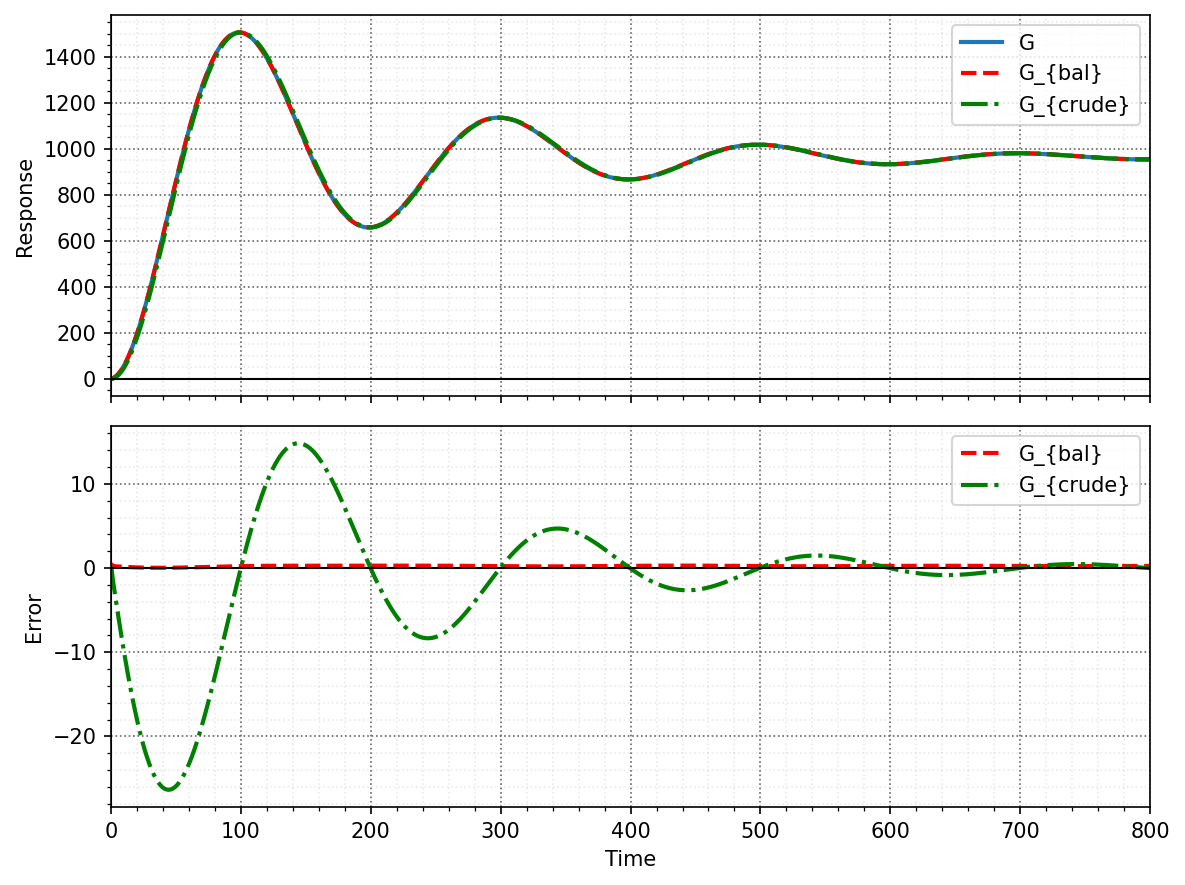

In [15]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
y,t = step(P,800)
yr,tr = step(Pr,t)
yrr,trr = step(Prr,t)
ax[0].plot(t,y,label='G')
ax[0].plot(tr,yr,'r--',label='G_{bal}')
ax[0].plot(trr,yrr,'g-.',label='G_{crude}')
ax[1].set_xlabel("Time")
ax[1].plot(t,yr-y,'r--',label='G_{bal}')
ax[1].plot(t,yrr-y,'g-.',label='G_{crude}')
ax[0].set_ylabel("Response")
ax[1].set_ylabel("Error")
ax[0].legend()
ax[1].legend()
nicegrid(ax)
savefig("./figs/DP_Ex42.pdf", dpi=600)
plt.show()